# Player Age Effect on Market Value

## Data Preprocessing

### Importing the libraries

In [270]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing and Cleaning Dataset

In [271]:
players = pd.read_csv('players.csv', usecols=['player_id','name','date_of_birth'])
vals    = pd.read_csv('player_valuations.csv', usecols=['player_id','date','market_value_in_eur'])

df = players.merge(vals, on='player_id', how='inner')


df = df.dropna()

# making age column (X)
dob  = pd.to_datetime(df['date_of_birth'])
date = pd.to_datetime(df['date'])

X = np.array((date - dob).dt.days / 365.25)

y = df.iloc[:, -1].values

In [272]:
print(X)
print(X.shape)
print(type(X))

[23.42778919 24.46269678 25.11978097 ... 22.52156057 22.69130732
 23.2881588 ]
(423823,)
<class 'numpy.ndarray'>


In [273]:
print(y)
print(y.shape)
print(type(y))

[ 7500000 10750000 11250000 ...    75000    75000    50000]
(423823,)
<class 'numpy.ndarray'>


### Plot the Data

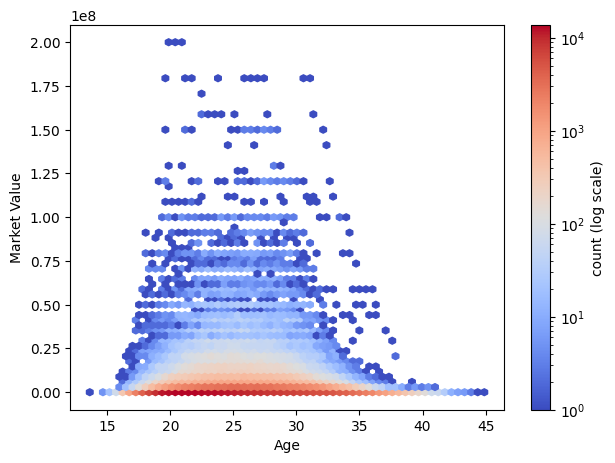

In [274]:
fig, ax = plt.subplots(figsize=(7, 5))

hb = ax.hexbin(X, y, gridsize=60, bins='log', mincnt=1, cmap = 'coolwarm')

cb = fig.colorbar(hb, ax=ax)
cb.set_label('count (log scale)')

ax.set_xlabel('Age')
ax.set_ylabel('Market Value')

plt.show()


>Data appears to be a parabola opening down, there for I assume the model will have a degree of 2.

>For this notebook I will use `hexbin()`, instead of `scatter()` as there are 423823 observations and the overlapping is misleading.





### Splitting the dataset into the Training set and Test set

In [275]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 74)

In [276]:
print(X_train)

[28.92539357 19.36208077 26.64476386 ... 28.41615332 19.57837098
 25.0294319 ]


In [277]:
print(X_test)

[24.29842574 23.78918549 20.5065024  ... 24.31759069 20.87063655
 34.84188912]


In [278]:
print(y_train)

[ 4000000  6000000 22000000 ...   500000   150000  1200000]


In [279]:
print(y_test)

[4000000  600000 8000000 ... 1000000  300000  400000]


## Polynomial Linear Regression

### Fitting on degree 2

In [280]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_reg_2 = PolynomialFeatures(degree = 2)
X_poly_2 = poly_reg_2.fit_transform(X_train.reshape(-1,1))
regressor_2 = LinearRegression()
regressor_2.fit(X_poly_2, y_train)

LinearRegression()

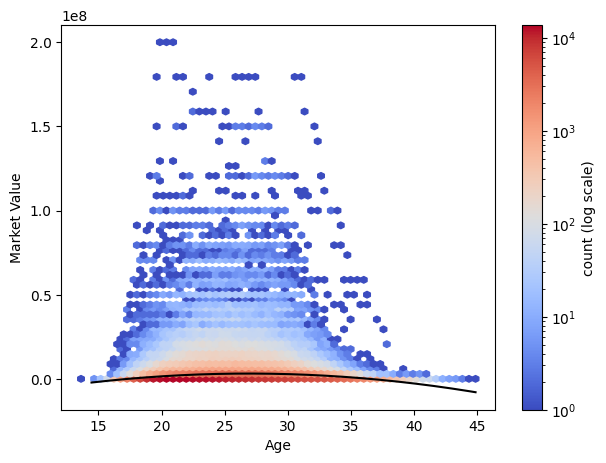

In [281]:
x_grid_2 = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
y_grid_2 = regressor_2.predict(poly_reg_2.transform(x_grid_2))

fig, ax = plt.subplots(figsize=(7, 5))

hb = ax.hexbin(X, y, gridsize=60, bins='log', mincnt=1, cmap = 'coolwarm')

cb = fig.colorbar(hb, ax=ax)
cb.set_label('count (log scale)')

ax.set_xlabel('Age')
ax.set_ylabel('Market Value')

ax.plot(x_grid_2, y_grid_2, color='black')

plt.show()

### Fitting on Degrees 1-12

In [282]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

r2_train = []
rmse_train = []
r2_test = []
rmse_test = []

for i in range(1,13):

  poly_reg = PolynomialFeatures(degree = i)
  X_poly = poly_reg.fit_transform(X_train.reshape(-1,1))
  regressor = LinearRegression()
  regressor.fit(X_poly, y_train)

  y_pred_train = regressor.predict(poly_reg.transform(X_train.reshape(-1,1)))
  y_pred_test = regressor.predict(poly_reg.transform(X_test.reshape(-1,1)))

  r2_train.append(r2_score(y_train, y_pred_train))
  rmse_train.append(root_mean_squared_error(y_train, y_pred_train))
  r2_test.append(r2_score(y_test, y_pred_test))
  rmse_test.append(root_mean_squared_error(y_test, y_pred_test))



### Plotting R2 and RMSE against Degree

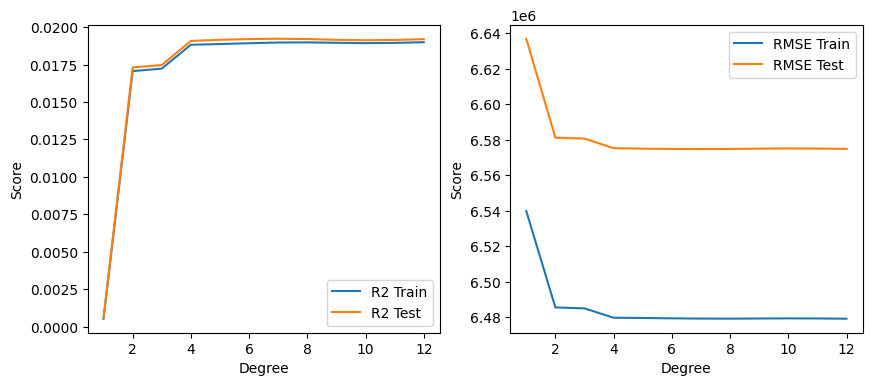

In [283]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(range(1,13), r2_train, label='R2 Train')
ax1.plot(range(1,13), r2_test, label='R2 Test')

ax1.set_xlabel('Degree')
ax1.set_ylabel('Score')

ax1.legend()


ax2.plot(range(1,13), rmse_train, label='RMSE Train')
ax2.plot(range(1,13), rmse_test, label='RMSE Test')

ax2.set_xlabel('Degree')
ax2.set_ylabel('Score')

ax2.legend()

plt.show()

### Analyzing the plot

> R2 increase and RMSE decreases significantly from degree 1 to degree 2 and contiues for 3 and 4 but they they both flatten out for the rest of the degrees. The training error curve doesnt go up, as a degree 4 can reproduce a degreee 3 model just by setting its top coeffecient to zero.

> RMSE is absolute so its comparable across different splits (as long as both models predict the same target in the same units). model trained on `X_train` performs better.

> R2 is almost identical with `X_test` slightly higher, as different spreads produce different values.

> Gaps are about the same throguhout, would be increasining if it were overfitting

> My guess of degree 2 turned out correct as the learning curve starts to flatten out starting degree 3

### Model Comparison

### Fitting on degree 12

In [284]:
poly_reg_12 = PolynomialFeatures(degree = 12)
X_poly_12 = poly_reg_12.fit_transform(X_train.reshape(-1,1))
regressor_12 = LinearRegression()
regressor_12.fit(X_poly_12, y_train)


LinearRegression()

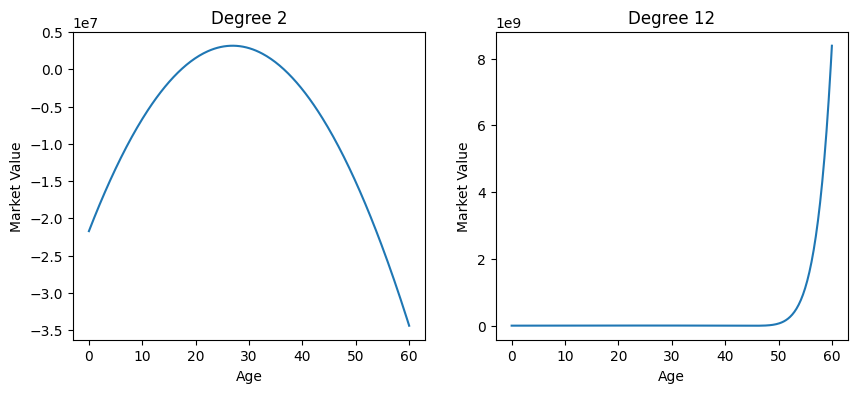

-------------------------------------------------------
regressor 2 coef: [      0.         1846838.27546006  -34302.84820563]
-------------------------------------------------------
regressor 2 intercept: -21709883.047263097
regressor 12 coef: [ 0.00000000e+00 -3.68609145e-11  9.16827093e-11  2.33552171e-09
  4.98822854e-08  9.11966743e-07  1.39103208e-05  1.62511173e-04
  1.12655796e-03 -1.11899861e-04  4.13519516e-06 -6.76498003e-08
  4.13603581e-10]
-------------------------------------------------------
regressor 12 intercept: -581562.871545542
-------------------------------------------------------
Degree 2:    0           -21,709,883
Degree 12:   0              -581,563
Degree 2:   10            -6,671,785
Degree 12:  10              -544,167
Degree 2:   20             1,505,743
Degree 12:  20             1,358,339
Degree 2:   30             2,822,702
Degree 12:  30             2,793,805
Degree 2:   40            -2,720,909
Degree 12:  40               632,221
Degree 2:   45    

In [288]:
x_grid_12 = np.linspace(0,60, 300).reshape(-1, 1)
y_grid_12 = regressor_12.predict(poly_reg_12.transform(x_grid_12))

x_grid_2 = np.linspace(0, 60, 300).reshape(-1, 1)
y_grid_2 = regressor_2.predict(poly_reg_2.transform(x_grid_2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x_grid_2, y_grid_2)
ax1.set_title('Degree 2')

ax1.set_xlabel('Age')
ax1.set_ylabel('Market Value')

ax2.plot(x_grid_12, y_grid_12)
ax2.set_title('Degree 12')

ax2.set_xlabel('Age')
ax2.set_ylabel('Market Value')

plt.show()

print('-------------------------------------------------------')
print(f'regressor 2 coef: {regressor_2.coef_}')
print('-------------------------------------------------------')
print(f'regressor 2 intercept: {regressor_2.intercept_}')
print('=======================================================')
print(f'regressor 12 coef: {regressor_12.coef_}')
print('-------------------------------------------------------')
print(f'regressor 12 intercept: {regressor_12.intercept_}')
print('-------------------------------------------------------')

for a in [0, 10, 20, 30, 40, 45, 50, 55, 60]:
    print(f'Degree 2:  {a:>3}  {regressor_2.predict(poly_reg_2.transform([[a]]))[0]:>20,.0f}')
    print(f'Degree 12: {a:>3}  {regressor_12.predict(poly_reg_12.transform([[a]]))[0]:>20,.0f}')




## Conclusion

> Clearly degree 12 isn't a good fit for the data with predictions like 8 billion market value at 60 years.

> Both models produce negative market values, the degree 2 model predicts negative market value for all players starting 35 and onwards, even though there are players in the training data who are 35 and older and obviously with a postive market value.

>Even though the degree 2 model had it flaws, a parabola is still the shape that fits the data, players start and end with a lower market value and have the highest market value in the peak of their career.

